In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import re
import string




In [25]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
class TweetCleaner:
    def __init__(self, filepath, encoding='latin1'):
        self.df = pd.read_csv(filepath, encoding=encoding)
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def preprocess_text(self, text):
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'http\S+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002700-\U000027BF"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def remove_stopwords(self, text):
        return ' '.join([word for word in text.split() if word not in self.stop_words])

    def lemmatize_text(self, text):
        return ' '.join([self.lemmatizer.lemmatize(word) for word in text.split()])

    def full_text_processing(self):
        self.df['processed_text'] = self.df['tweet_text'].astype(str).apply(self.preprocess_text)
        self.df['processed_text'] = self.df['processed_text'].apply(self.remove_stopwords)
        self.df['processed_text'] = self.df['processed_text'].apply(self.lemmatize_text)
        return self.df

    
    def handle_missing_values(self):
        self.df = self.df.dropna(subset=['tweet_text'])
        self.df['emotion_in_tweet_is_directed_at'] = self.df['emotion_in_tweet_is_directed_at'].fillna('Unknown')
        return self.df


In [27]:
cleaner = TweetCleaner('judge-1377884607_tweet_product_company.csv', encoding='latin1')
cleaner.full_text_processing()
cleaner.handle_missing_values()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,processed_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,3g iphone 3 hr tweeting dead need upgrade plug...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,wait 2 also sale
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...
...,...,...,...,...
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion,ipad everywhere link
9089,"Wave, buzz... RT @mention We interrupt your re...",Unknown,No emotion toward brand or product,wave buzz rt interrupt regularly scheduled gee...
9090,"Google's Zeiger, a physician never reported po...",Unknown,No emotion toward brand or product,google zeiger physician never reported potenti...
9091,Some Verizon iPhone customers complained their...,Unknown,No emotion toward brand or product,verizon iphone customer complained time fell b...


In [28]:
cleaner.df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9092 entries, 0 to 9092
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     9092 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9092 non-null   object
 3   processed_text                                      9092 non-null   object
dtypes: object(4)
memory usage: 355.2+ KB


In [29]:
cleaner.df.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,processed_text
count,9092,9092,9092,9092
unique,9065,10,4,8640
top,RT @mention Marissa Mayer: Google Will Connect...,Unknown,No emotion toward brand or product,rt google launch major new social network call...
freq,5,5801,5388,26


In [30]:
cleaner.df.shape

(9092, 4)

In [31]:
# Remove duplicates
cleaner.df = cleaner.df.drop_duplicates(subset=['tweet_text'])
cleaner.df = cleaner.df[~cleaner.df['processed_text'].str.contains('�')]

In [32]:
cleaner.df.isnull().sum()

tweet_text                                            0
emotion_in_tweet_is_directed_at                       0
is_there_an_emotion_directed_at_a_brand_or_product    0
processed_text                                        0
dtype: int64

In [33]:
# Encode target variable
le = LabelEncoder()
cleaner.df['emotion_encoded'] = le.fit_transform(cleaner.df['is_there_an_emotion_directed_at_a_brand_or_product'])
cleaner.df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,processed_text,emotion_encoded
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,3g iphone 3 hr tweeting dead need upgrade plug...,1
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...,3
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,wait 2 also sale,3
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app,1
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...,3


In [34]:
# Prepare features and target
X = cleaner.df['processed_text']
y = cleaner.df['emotion_encoded']

In [35]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [36]:
# Compute class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))


In [37]:
# Define ML pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]),
    'SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', SVC(class_weight='balanced', probability=True))
    ])
}


In [38]:
# Define parameter grids for GridSearchCV
param_grids = {
    'Logistic Regression': {
        'tfidf__max_features': [3000, 5000],
        'clf__C': [0.1, 1, 10]
    },
    'Decision Tree': {
        'tfidf__max_features': [3000, 5000],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5]
    },
    'Random Forest': {
        'tfidf__max_features': [3000, 5000],
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [None, 10]
    },
    'SVM': {
        'tfidf__max_features': [3000, 5000],
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear']
    },
    'Linear SVC': {
        'tfidf__max_features': [3000, 5000],
        'clf__C': [0.1, 1, 10]
    }
}


--- Logistic Regression ---
Best Parameters: {'clf__C': 10, 'tfidf__max_features': 5000}
Best CV Score (F1-weighted): 0.6269267708738235
Test Accuracy: 0.6309983452840596
Classification Report:
                                     precision    recall  f1-score   support

                      I can't tell       0.04      0.06      0.05        31
                  Negative emotion       0.35      0.50      0.41       114
No emotion toward brand or product       0.76      0.67      0.71      1074
                  Positive emotion       0.55      0.62      0.59       594

                          accuracy                           0.63      1813
                         macro avg       0.43      0.46      0.44      1813
                      weighted avg       0.66      0.63      0.64      1813



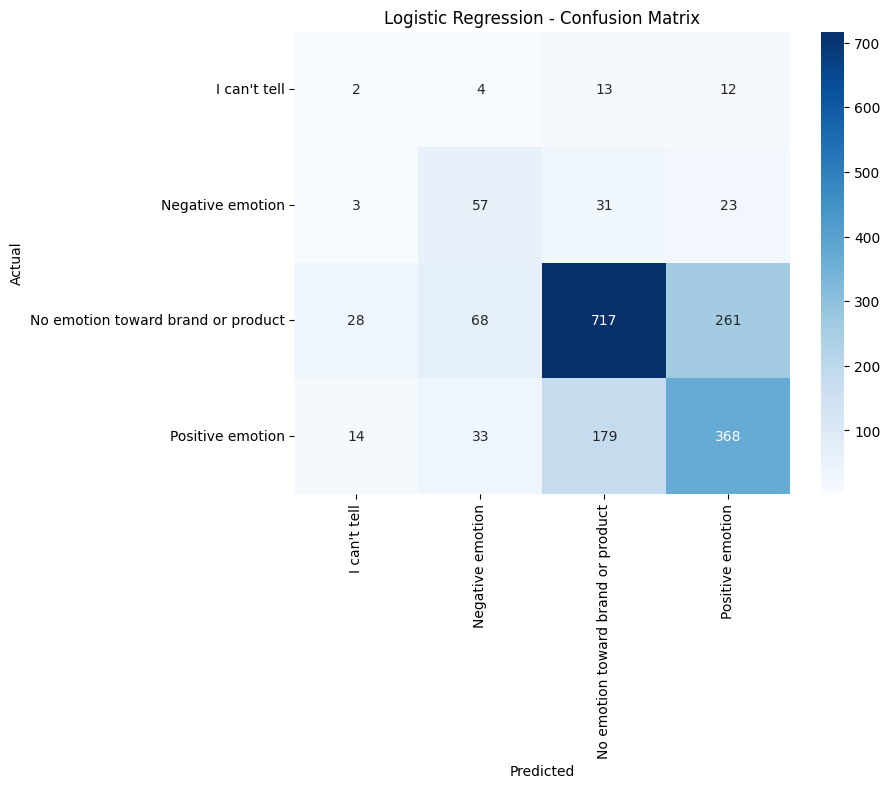


--- Random Forest ---
Best Parameters: {'clf__max_depth': None, 'clf__n_estimators': 200, 'tfidf__max_features': 5000}
Best CV Score (F1-weighted): 0.6261657604267494
Test Accuracy: 0.6591285162713734
Classification Report:
                                     precision    recall  f1-score   support

                      I can't tell       0.08      0.03      0.05        31
                  Negative emotion       0.61      0.19      0.29       114
No emotion toward brand or product       0.68      0.85      0.76      1074
                  Positive emotion       0.62      0.43      0.51       594

                          accuracy                           0.66      1813
                         macro avg       0.50      0.38      0.40      1813
                      weighted avg       0.64      0.66      0.63      1813



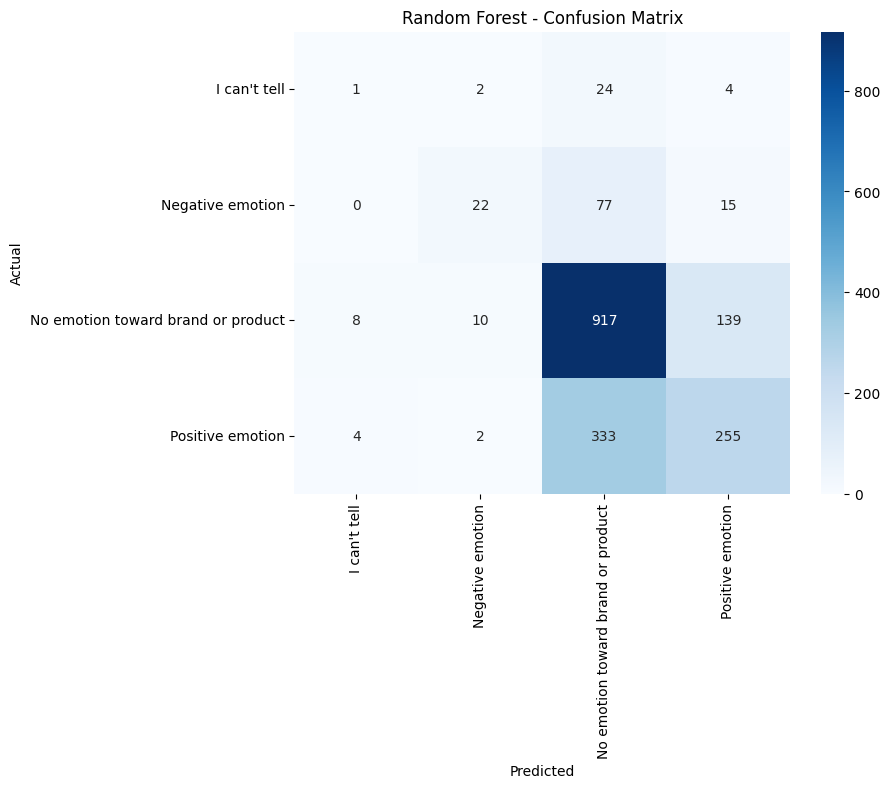


--- SVM ---
Best Parameters: {'clf__C': 10, 'clf__kernel': 'rbf', 'tfidf__max_features': 5000}
Best CV Score (F1-weighted): 0.642814697294886
Test Accuracy: 0.6767788196359625
Classification Report:
                                     precision    recall  f1-score   support

                      I can't tell       0.07      0.03      0.04        31
                  Negative emotion       0.55      0.30      0.39       114
No emotion toward brand or product       0.72      0.79      0.76      1074
                  Positive emotion       0.61      0.58      0.59       594

                          accuracy                           0.68      1813
                         macro avg       0.49      0.42      0.44      1813
                      weighted avg       0.66      0.68      0.67      1813



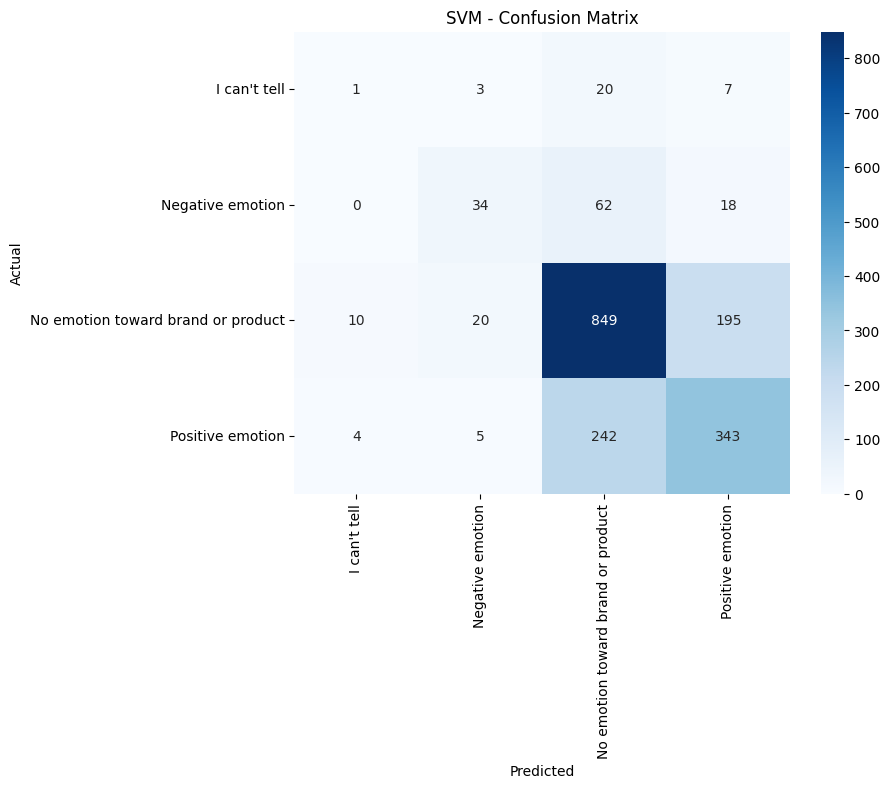

In [39]:
# Train and evaluate models with GridSearchCV
best_models = {}
for name, pipeline in pipelines.items():
    print(f"\n--- {name} ---")
    grid = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    
    print("Best Parameters:", grid.best_params_)
    print("Best CV Score (F1-weighted):", grid.best_score_)
    
    # Evaluate on test set
    y_pred = grid.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [53]:
param_grids['Logistic Regression'] = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

In [56]:
# Define pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Define param_grid with correct step names
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']
}

# Run GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}


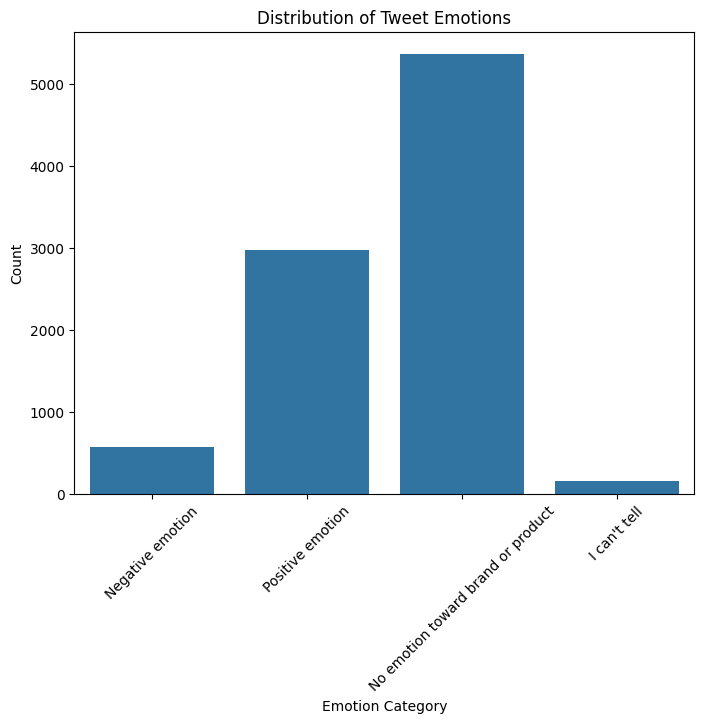

In [58]:
# Class Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(data=cleaner.df, x='is_there_an_emotion_directed_at_a_brand_or_product')
plt.title('Distribution of Tweet Emotions')
plt.xlabel('Emotion Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()